In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

# filter dataframe to have only data analyst job postings
df_da = df.loc[df["job_title_short"] == "Data Analyst"].reset_index().copy()

## Plot 1: top 5 skills for data analysts per month

In [ ]:
# drop index column
df_da.drop(columns="index", inplace=True)

In [ ]:
# create month number column
df_da["job_posted_month"] = df_da["job_posted_date"].dt.month

In [17]:
# explode and pivot table
explode_df = df_da.explode("job_skills")
aggregation_df = explode_df.pivot_table(index="job_posted_month", columns="job_skills", aggfunc="size", fill_value=0)

In [24]:
# add total row and sort values
aggregation_df.loc["Total"] = aggregation_df.sum()
aggregation_df.sort_values(by="Total", axis=1, ascending=False, inplace=True)

In [ ]:
# filter for top 5 skills
filtered_df = aggregation_df.iloc[:, :5]

In [ ]:
# drop last row of the dataframe
final_df = filtered_df.drop(filtered_df.index[len(filtered_df) - 1])

In [ ]:
# change months for abreviations
import calendar
final_df.index = [calendar.month_abbr[month] for month in final_df.index]

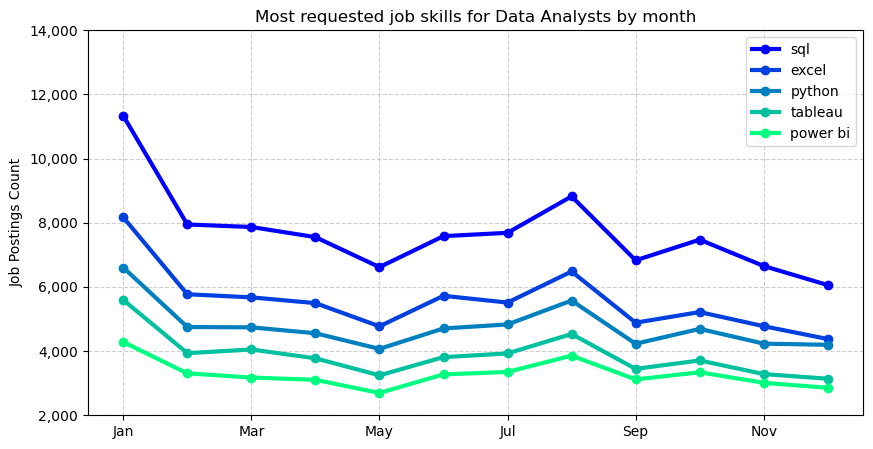

In [94]:
# create plot
final_df.plot(
    kind='line',
    linewidth=3,
    colormap="winter",
    marker="o",
    markersize=6,
    figsize=(10, 5)
)

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"{int(y):,}"))

plt.title("Most requested job skills for Data Analysts by month")
plt.grid(True, alpha=0.6, linestyle="--")
plt.legend(title="")
plt.ylim(2000, 14000)
plt.ylabel("Job Postings Count")
plt.show()

## Plot 2: job skills insights 

In [67]:
# explode df
exploded_df = df_da.explode("job_skills")

In [75]:
# do aggregation of count and median salary
groupby_df = exploded_df.groupby("job_skills").agg(
    median_yearly_salary=("salary_year_avg", "median"),
    job_count=("job_title_short", "size")
).sort_values(by="job_count", ascending=False).head(20)
groupby_df

,median_yearly_salary,job_count
job_skills,,
sql,92500.000000,92428
excel,84479.000000,66860
python,98500.000000,57190
tableau,95000.000000,46455
power bi,90000.000000,39380
r,92527.500000,29996
sas,90000.000000,27998
powerpoint,85000.000000,13822
word,80000.000000,13562


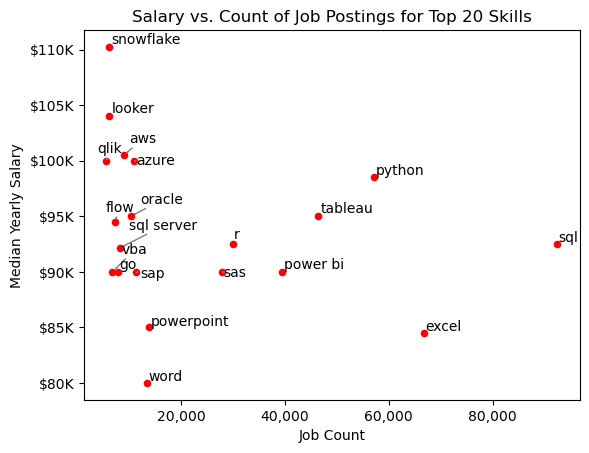

In [ ]:
# create plot, format text position with the adjust_text function and format yaxis label with an f-string
from adjustText import adjust_text

groupby_df.plot(kind="scatter", x="job_count", y="median_yearly_salary", color="red")
plt.ylabel("Median Yearly Salary")
plt.xlabel("Job Count")
plt.title("Salary vs. Count of Job Postings for Top 20 Skills")

texts = []
for i, skill in enumerate(groupby_df.index):
    texts.append(plt.text(x=groupby_df["job_count"].iloc[i], y=groupby_df["median_yearly_salary"].iloc[i], s=skill))
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y / 1000)}K"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x):,}"))

plt.show()